# Л1 — Підготовка даних

Велика частина роботи в Data Science — збір і підготовка даних. Саме тут виникає багато неочікуваних проблем і пасток.

Ноутбук нижче базово показує, як працювати з даними й готувати їх. Він не охоплює всіх можливих сценаріїв, а приклади в ньому часом сильно спрощені. Проте він дасть розуміння, де шукати помилки і як з ними боротися. Більше туторіалів — у [Kaggle Learn](https://www.kaggle.com/learn), зокрема [Data Cleaning](https://www.kaggle.com/learn/data-cleaning).

Базовий алгоритм підготовки даних може виглядати так (у дужках — кроки цього ноутбука):

- зчитування даних і початкове дослідження (1);
- дослідження структури й особливостей даних, зміна типів (2);
- об'єднання даних з різних джерел (3–4);
- робота з пропущеними й зламаними значеннями: drop, fill тощо (5, 7, 8);
- пошук outliers: drop, clip тощо (6);
- пошук зайвих і бракуючих колонок (9).

І головне: з кожною дією треба бути обережним. Outliers можуть бути реальними даними, які логічно пояснюються і які не можна видаляти. А пропущені значення можуть щось означати й бути корисними. Обидва випадки є в цій роботі.

Далі бувають кроки, специфічні для певних моделей чи алгоритмів:

- scaling: normalization, standardization тощо;
- обробка категорійних колонок: one-hot encoding тощо;
- dimensionality reduction.

Тут вони не розглядаються, частину з них побачите в Л2 і Л3.

Шаблон веде покроково: у кожному кроці — навіщо він і що зробити, у клітинці з `TODO` — ваш код. Опис даних і таблиця недоліків — у `README.md`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

VARIANT = 0
DATA_DIR = f"variants/{VARIANT}/"

PERIOD_START = pd.Timestamp("2026-01-05 00:00")
PERIOD_END = pd.Timestamp("2026-02-01 23:00")
DISTRICTS = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
KWH_LIMITS = {"household": (0.01, 10), "small_business": (0.02, 60), "industrial": (1, 1200)}


def show_threshold_split(label, values, is_flagged):
    """Скільки лічильників за порогом і діапазони значень обох груп — доказ для звіту."""
    normal, flagged = values[~is_flagged], values[is_flagged]
    print(f"{label}: {is_flagged.sum()} з {len(values)}")
    print(f"  решта:     від {normal.min():.4g} до {normal.max():.4g}")
    if is_flagged.any():
        print(f"  виявлені:  від {flagged.min():.4g} до {flagged.max():.4g}")


def count_out_of_limits(frame):
    """Кількість рядків, де споживання поза межами для свого customer_type."""
    low = frame["customer_type"].map(lambda kind: KWH_LIMITS[kind][0])
    high = frame["customer_type"].map(lambda kind: KWH_LIMITS[kind][1])
    return (~frame["consumption_kwh"].between(low, high)).sum()

## 1. Завантаження даних

На цьому етапі важливо впевнитися, що файли завантажено правильно, і подивитися, що взагалі всередині. Можуть допомогти `df.head()`, `df.tail()`, `df.shape` і `df.dtypes`.

Що ви маєте зрозуміти?

- Чи зчиталися дані взагалі?
- Чи правильно розпарсилися рядки, колонки й значення?
- Які типи в колонок?
- Які приблизно значення?
- Скільки рядків і колонок?

In [2]:
df_meters = pd.read_parquet(DATA_DIR + "meters.parquet")
df_registry = pd.read_csv(DATA_DIR + "registry.csv")

print("meters.parquet:", df_meters.shape)
print(df_meters.dtypes, end="\n\n")
print("registry.csv:", df_registry.shape)
print(df_registry.dtypes)
display(df_meters.head(), df_registry.head())

meters.parquet: (540022, 4)
meter_id                      str
ts                 datetime64[us]
consumption_kwh           float64
record_ts          datetime64[us]
dtype: object

registry.csv: (800, 7)
meter_id              str
customer_type         str
tariff                str
electric_heating    int64
connection_year     int64
years_connected     int64
district              str
dtype: object


,meter_id,ts,consumption_kwh,record_ts
0,UA100509,2026-01-05 00:00:00,0.1569,2026-01-05 00:04:31
1,UA100509,2026-01-05 01:00:00,0.1266,2026-01-05 01:09:08
2,UA100509,2026-01-05 02:00:00,0.1002,2026-01-05 02:07:32
3,UA100509,2026-01-05 03:00:00,0.0948,2026-01-05 03:07:45
4,UA100509,2026-01-05 04:00:00,0.1189,2026-01-05 04:11:51


,meter_id,customer_type,tariff,electric_heating,connection_year,years_connected,district
0,UA100509,household,single,0,1990,36,Darnytsia
1,UA102079,household,single,0,2007,19,Podil
2,UA105022,small_business,single,0,2005,20,OBOLON
3,UA108159,small_business,single,0,1985,41,Solomianka
4,UA111472,household,dual_zone,1,1991,35,Obolon


## 2. Звірка з описом

Іноді бізнес надає опис ідеальних даних, але реальні дані часто з ним не збігаються. Тому спершу подивіться, чи ваші дані відповідають опису в `README.md`. Може допомогти `df.describe()`.

Перевірте (але поки не виправляйте):

- типи колонок: якщо число прочиталося як текст, частина операцій спрацює неправильно;
- скільки рядків мають `customer_type`, `tariff` чи `electric_heating`, яких немає в описі;
- скільки рядків мають `ts`, `connection_year` чи `years_connected` поза межами з опису;
- скільки різних лічильників у кожному файлі — мають бути по 800.

Можуть допомогти `isin`, `between` і `nunique`.

Недоліки з таблиці в `README.md` перевірятимете далі, кожен у своєму кроці. Межі споживання залежать від типу абонента, а тип є лише в реєстрі, тому їх перевірите після об'єднання, на кроці 6.

In [3]:
allowed_values = {
    "customer_type": ["household", "small_business", "industrial"],
    "tariff": ["single", "dual_zone"],
    "electric_heating": [0, 1],
}
for column, allowed in allowed_values.items():
    print(f"{column}: значень поза описом — {(~df_registry[column].isin(allowed)).sum()}")

value_ranges = {"connection_year": (1985, 2024), "years_connected": (1, 41)}
for column, (low, high) in value_ranges.items():
    print(f"{column}: поза [{low}, {high}] — {(~df_registry[column].between(low, high)).sum()}")

ts_outside = ~df_meters["ts"].between(PERIOD_START, PERIOD_END)
print(f"ts: поза періодом — {ts_outside.sum()}")
print("пропусків у meters:", df_meters.isna().sum().sum(), "| у registry:", df_registry.isna().sum().sum())
print("лічильників у meters:", df_meters["meter_id"].nunique(), "| у registry:", df_registry["meter_id"].nunique())
display(df_meters.describe(), df_registry.describe())

customer_type: значень поза описом — 0
tariff: значень поза описом — 0
electric_heating: значень поза описом — 0
connection_year: поза [1985, 2024] — 0
years_connected: поза [1, 41] — 0
ts: поза періодом — 0
пропусків у meters: 0 | у registry: 0
лічильників у meters: 800 | у registry: 800


,ts,consumption_kwh,record_ts
count,540022,540022.000000,540022
mean,2026-01-18 23:30:00.906629,462.201217,2026-01-18 23:52:29.374919
min,2026-01-05 00:00:00,0.017400,2026-01-05 00:01:00
25%,2026-01-11 23:00:00,0.408200,2026-01-12 00:04:35.250000
50%,2026-01-19 00:00:00,0.901600,2026-01-19 00:04:50
75%,2026-01-25 23:00:00,2.679075,2026-01-26 00:03:35.250000
max,2026-02-01 23:00:00,181047.500000,2026-02-02 22:53:11
std,NaN,4476.906768,NaN


,electric_heating,connection_year,years_connected
count,800.000000,800.000000,800.000000
mean,0.203750,2004.365000,21.136250
std,0.403037,11.376447,11.404836
min,0.000000,1985.000000,1.000000
25%,0.000000,1995.000000,12.000000
50%,0.000000,2004.000000,21.000000
75%,0.000000,2014.000000,31.000000
max,1.000000,2024.000000,41.000000


## 3. Реєстр: номери й райони (D-E, D-F)

Дані зберігаються в різних системах, тому формат ідентифікатора може не збігатися: `" UA123456"` для pandas — інший номер, ніж `UA123456`. Наївний join призведе до того, що частина даних втратиться. Так само `podil` і `Podil` — різні райони, і будь-який підрахунок по районах буде хибним.

Для D-E і D-F виведіть, скільки рядків реєстру зіпсовано, і виправте їх так, як сказано в таблиці недоліків. Можуть допомогти `str.fullmatch(r"UA\d{6}")`, `isin`, `str.strip()`, `str.lstrip("0")` і `str.capitalize()`.

In [4]:
# D-E: номери не у вигляді UA і 6 цифр
bad_ids = ~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")
print("D-E: зіпсованих номерів у реєстрі:", bad_ids.sum())
print("  приклади:", df_registry.loc[bad_ids, "meter_id"].head().tolist())
df_registry["meter_id"] = df_registry["meter_id"].str.strip().str.lstrip("0")
print("  після виправлення зіпсованих:", (~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")).sum())
print("  спільних номерів із meters:", df_registry["meter_id"].isin(df_meters["meter_id"]).sum())

# D-F: райони, написані не як в описі
bad_districts = ~df_registry["district"].isin(DISTRICTS)
print("D-F: рядків із неправильним district:", bad_districts.sum())
print("  варіанти написання:", sorted(df_registry.loc[bad_districts, "district"].unique()))
df_registry["district"] = df_registry["district"].str.strip().str.capitalize()
print("  після виправлення:", (~df_registry["district"].isin(DISTRICTS)).sum())
print(df_registry["district"].value_counts())

D-E: зіпсованих номерів у реєстрі: 96
  приклади: ['UA111472 ', 'UA121219 ', 'UA127782 ', 'UA128946 ', '00UA168122']
  після виправлення зіпсованих: 0


  спільних номерів із meters: 800
D-F: рядків із неправильним district: 80
  варіанти написання: ['DARNYTSIA', 'Darnytsia ', 'OBOLON', 'Obolon ', 'PODIL', 'Podil ', 'SOLOMIANKA', 'SVIATOSHYN', 'Solomianka ', 'Sviatoshyn ', 'darnytsia', 'obolon', 'podil', 'solomianka', 'sviatoshyn']
  після виправлення: 0
district
Solomianka    194
Podil         189
Darnytsia     157
Obolon        142
Sviatoshyn    118
Name: count, dtype: int64


## 4. Об'єднання

Тепер погодинні дані можна об'єднати з реєстром за `meter_id` (join, у pandas — `merge`). pandas не попереджає, коли рядок не знайшов пари, тому якість об'єднання треба перевірити самому.

Об'єднану таблицю назвіть `df`, з нею працюватимете далі. Перевірте й виведіть:

- кількість рядків до і після об'єднання — вона не має змінитися;
- кількість рядків без атрибутів абонента (пропуск у `customer_type`) — має бути 0.

Може допомогти `merge(..., how="left", validate="m:1")`: `validate` ще й перевірить, що кожному лічильнику відповідає один рядок реєстру.

In [5]:
rows_before_merge = len(df_meters)
df = df_meters.merge(df_registry, on="meter_id", how="left", validate="m:1")

print("рядків до об'єднання:", rows_before_merge, "| після:", len(df))
print("рядків без атрибутів абонента:", df["customer_type"].isna().sum())

рядків до об'єднання: 540022 | після: 540022
рядків без атрибутів абонента: 0


## 5. Повторні відправки (D-C)

Повторна відправка — та сама година того самого лічильника ще раз, іноді з уточненим значенням. Якщо лишити обидва записи, споживання за цю годину подвоїться. Лишаємо найпізніший за `record_ts` запис як найсвіжіший.

Виведіть кількість рядків і кількість різних пар `meter_id` і `ts`, потім зніміть повтори. Можуть допомогти `duplicated(["meter_id", "ts"])`, `sort_values("record_ts")` і `drop_duplicates(["meter_id", "ts"], keep="last")`.

In [6]:
rows_with_repeats = len(df)
unique_pairs = len(df.drop_duplicates(["meter_id", "ts"]))
print("D-C: рядків:", rows_with_repeats, "| різних пар meter_id і ts:", unique_pairs,
      "| зайвих рядків:", rows_with_repeats - unique_pairs)

df = (df.sort_values("record_ts")
        .drop_duplicates(["meter_id", "ts"], keep="last")
        .sort_values(["meter_id", "ts"])
        .reset_index(drop=True))
print("рядків після зняття повторів:", len(df))

D-C: рядків: 540022 | різних пар meter_id і ts: 529555 | зайвих рядків: 10467


рядків після зняття повторів: 529555


## 6. Одиниці виміру (D-D)

Значення у Вт·год схожі на викиди, але це не шум, а помилка одиниць. Якщо їх видалити, зникнуть цілі абоненти.

1. Для кожного лічильника порахуйте відношення його медіани `consumption_kwh` до медіани всіх рядків його `customer_type`. Більше 100 — лічильник звітує у Вт·год.
2. Побудуйте графік медіан лічильників за `customer_type` з логарифмічною віссю, наприклад boxplot.
3. Виведіть кількість лічильників у Вт·год, найбільше відношення серед решти лічильників і найменше серед лічильників у Вт·год (якщо таких немає — лише найбільше відношення серед усіх). Ці числа — доказ у звіті: вони показують, наскільки далеко від порога обидві групи.
4. Поділіть значення цих лічильників на 1000 і виведіть, скільки рядків поза межами споживання з опису, — має бути 0.

Можуть допомогти `DataFrame.boxplot(column=..., by="customer_type")`, `plt.yscale("log")` і `between`. Клітинку з діленням не запускайте двічі: значення поділяться ще раз. Якщо так сталося, перезапустіть ноутбук з початку.

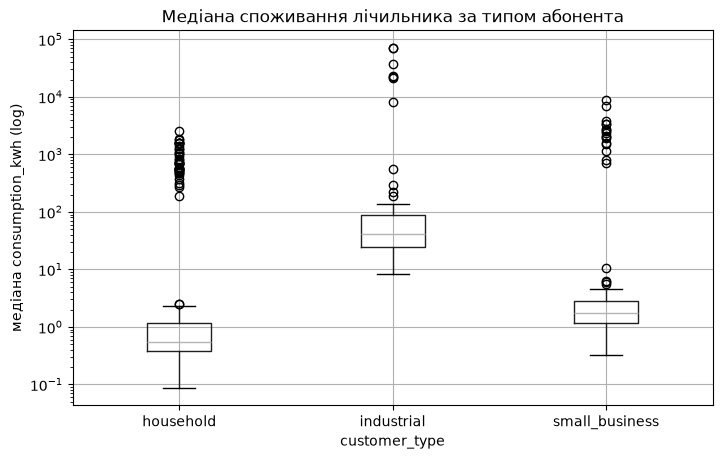

D-D: лічильників у Вт·год (відношення медіан > 100): 64 з 800
  решта:     від 0.1407 до 13.59
  виявлені:  від 197.4 до 4741


рядків поза межами споживання до ділення: 42321


рядків поза межами споживання після ділення: 0


In [7]:
meter_median = df.groupby("meter_id")["consumption_kwh"].median()
meter_type = df.groupby("meter_id")["customer_type"].first()
type_median = df.groupby("customer_type")["consumption_kwh"].median()
ratio = meter_median / meter_type.map(type_median)

pd.DataFrame({"median_kwh": meter_median, "customer_type": meter_type}).boxplot(
    column="median_kwh", by="customer_type", figsize=(8, 5))
plt.yscale("log")
plt.title("Медіана споживання лічильника за типом абонента")
plt.suptitle("")
plt.ylabel("медіана consumption_kwh (log)")
plt.show()

is_watt_hours = ratio > 100
show_threshold_split("D-D: лічильників у Вт·год (відношення медіан > 100)", ratio, is_watt_hours)
watt_hour_meters = list(ratio[is_watt_hours].index)

print("рядків поза межами споживання до ділення:", count_out_of_limits(df))
df.loc[df["meter_id"].isin(watt_hour_meters), "consumption_kwh"] /= 1000
print("рядків поза межами споживання після ділення:", count_out_of_limits(df))

## 7. Лічильники, що замовкли (D-A)

Пропуски не заповнюємо: те, що лічильник замовк, уже є інформацією про можливу відмову, а середнє її стерло б. Не видаляємо теж: до відмови лічильник передавав правильні дані.

Для кожного лічильника порахуйте, скільки годин минуло від його останнього `ts` до `2026-02-01 23:00`; більше 48 — замовк. Як на кроці 6, виведіть кількість замовклих, найбільшу тишу серед решти й найменшу серед замовклих (якщо замовклих немає — лише найбільшу тишу серед усіх).

Номери замовклих лічильників збережіть списком `silent`, наприклад `list(....index)`: він знадобиться в регресії.

Можуть допомогти `pd.Timestamp("2026-02-01 23:00")` і `/ pd.Timedelta(hours=1)`.

In [8]:
last_record = df.groupby("meter_id")["ts"].max()
silence_hours = (PERIOD_END - last_record) / pd.Timedelta(hours=1)

is_silent = silence_hours > 48
show_threshold_split("D-A: замовклих лічильників (тиша > 48 год)", silence_hours, is_silent)
silent = list(silence_hours[is_silent].index)

D-A: замовклих лічильників (тиша > 48 год): 0 з 800
  решта:     від 0 до 1


## 8. Завмерлі лічильники (D-B)

Завмерлі значення виглядають правдоподібно, і ні середнє, ні максимум їх не видають. Помітно лише те, що значення перестали змінюватися. Такі лічильники не видаляємо: частина їхніх годин справна.

Для кожного лічильника порахуйте частку різних значень `consumption_kwh` серед його записів; менше 0.65 — завмер. Побудуйте гістограму цієї частки по лічильниках. Як на кроці 6, виведіть кількість завмерлих, найменшу частку серед решти й найбільшу серед завмерлих (якщо завмерлих немає — лише найменшу частку серед усіх).

Номери завмерлих лічильників збережіть списком `frozen`: він знадобиться в регресії.

Можуть допомогти `nunique()`, `size()` і `plt.hist`.

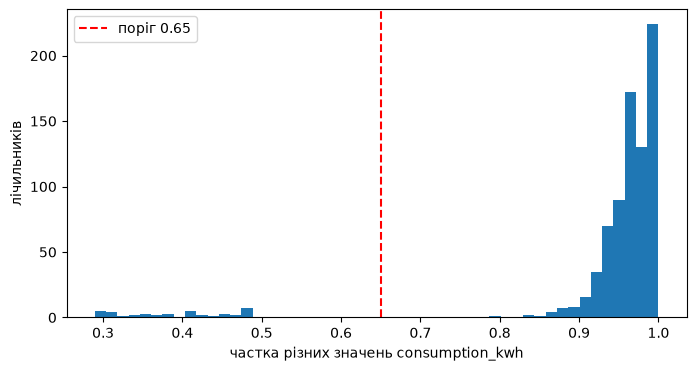

D-B: завмерлих лічильників (частка < 0.65): 40 з 800
  решта:     від 0.8006 до 1
  виявлені:  від 0.2896 до 0.485


In [9]:
records_per_meter = df.groupby("meter_id")["consumption_kwh"]
distinct_share = records_per_meter.nunique() / records_per_meter.size()

plt.figure(figsize=(8, 4))
plt.hist(distinct_share, bins=50)
plt.axvline(0.65, color="red", linestyle="--", label="поріг 0.65")
plt.xlabel("частка різних значень consumption_kwh")
plt.ylabel("лічильників")
plt.legend()
plt.show()

is_frozen = distinct_share < 0.65
show_threshold_split("D-B: завмерлих лічильників (частка < 0.65)", distinct_share, is_frozen)
frozen = list(distinct_share[is_frozen].index)

## 9. Кореляції

Колонка, що майже копіює іншу, не додає інформації: у кластеризації вона подвоює вагу того самого фактора, а в регресії робить коефіцієнти нестабільними. Технічна колонка `record_ts` після кроку 5 теж не потрібна.

Порахуйте кореляції між числовими колонками об'єднаної таблиці. Пару з кореляцією за модулем понад 0.95 вважайте копією і лиште з неї одну колонку. Приберіть `record_ts`. Підсумкову таблицю назвіть `result`.

Можуть допомогти `select_dtypes("number").corr().abs()` і `drop(columns=...)`.

In [10]:
correlations = df.select_dtypes("number").corr().abs()
display(correlations.round(4))

copy_pairs = [(first, second) for first in correlations for second in correlations
              if first < second and correlations.loc[first, second] > 0.95]
print("пари-копії:", [(first, second, round(correlations.loc[first, second], 4)) for first, second in copy_pairs])

# з кожної пари лишаємо connection_year — він у реєстрі первинний, а years_connected із нього виводиться
duplicate_columns = [second if first == "connection_year" else first for first, second in copy_pairs]
result = df.drop(columns=duplicate_columns + ["record_ts"])
print("прибрано:", duplicate_columns + ["record_ts"])
print("колонки результату:", list(result.columns))

,consumption_kwh,electric_heating,connection_year,years_connected
consumption_kwh,1.0000,0.0846,0.0193,0.0184
electric_heating,0.0846,1.0000,0.0566,0.0548
connection_year,0.0193,0.0566,1.0000,0.9990
years_connected,0.0184,0.0548,0.9990,1.0000


пари-копії: [('connection_year', 'years_connected', np.float64(0.999))]
прибрано: ['years_connected', 'record_ts']
колонки результату: ['meter_id', 'ts', 'consumption_kwh', 'customer_type', 'tariff', 'electric_heating', 'connection_year', 'district']


## 10. Самоперевірка й збереження

Якщо якась перевірка падає, поверніться до відповідного кроку.

In [11]:
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
corr = result.select_dtypes("number").corr().abs()
copies = [(a, b) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]

assert not result.duplicated(["meter_id", "ts"]).any(), "лишилися повтори лічильник–година"
assert result["meter_id"].nunique() == 800, "лічильників має бути 800"
assert result["meter_id"].str.fullmatch(r"UA\d{6}").all(), "є номери не у форматі UA і 6 цифр"
assert result["customer_type"].notna().all(), "є рядки без атрибутів абонента"
assert result["district"].isin(districts).all(), "є райони, яких немає в описі"
assert result["consumption_kwh"].between(result["customer_type"].map(min_kwh), result["customer_type"].map(max_kwh)).all(), "є споживання поза межами з опису"
assert not copies, f"лишилися колонки-копії: {copies}"
assert "record_ts" not in result, "технічна колонка record_ts лишилася"

result.to_parquet("cleaned.parquet", index=False)
print("усе гаразд:", result.shape)

усе гаразд: (529555, 8)


## 11. Регресія

Регресію часто використовують, щоб передбачати певні показники. Проте лінійна регресія також показує, як кожен показник впливає на результат. Це і є регресійний аналіз.

Для прикладу подивимося, як на добове споживання домогосподарства впливають електроопалення і двозонний тариф: `y = a + b₁·x₁ + b₂·x₂`.

- `y` — середнє споживання лічильника за добу, кВт·год;
- `x₁` — `electric_heating`, `x₂` — двозонний тариф (обидва 0 або 1);
- `b₁` і `b₂` — на скільки кВт·год на добу більше споживає абонент із цим фактором за однакового іншого;
- `a` — споживання без опалення на звичайному тарифі;
- R² — яку частку розкиду споживання пояснюють обидва фактори, від 0 до 1.

Регресія тут краща за просте порівняння середніх: двозонний тариф здебільшого мають будинки з опаленням, і різниця середніх за тарифом приписала б тарифу ще й споживання на опалення.

Нормалізація не потрібна: обидва фактори мають однаковий масштаб (0 або 1), тож `b₁` і `b₂` можна порівнювати напряму, а `y` лишається в кВт·год на добу, і коефіцієнти легко пояснити. Якби фактори мали різні одиниці, наприклад площу і рік, для порівняння впливу їх спершу стандартизували б.

Лічильники з `silent` і `frozen` не беремо: у `cleaned.parquet` вони лишаються, але їхнє середнє споживання спотворене.

Код майже готовий: допишіть `homes` і запустіть.

In [12]:
homes = result[(result["customer_type"] == "household") & ~(result["meter_id"].isin(silent + frozen))]

per_meter = homes.groupby("meter_id").agg(
    kwh_per_day=("consumption_kwh", "mean"),
    electric_heating=("electric_heating", "first"),
    tariff=("tariff", "first"),
)
per_meter["kwh_per_day"] *= 24
per_meter["dual_zone"] = (per_meter["tariff"] == "dual_zone").astype(int)

x, y = per_meter[["electric_heating", "dual_zone"]], per_meter["kwh_per_day"]
model = LinearRegression().fit(x, y)
print("лічильників:", len(per_meter))
print(f"a = {model.intercept_:.2f}, b₁ (опалення) = {model.coef_[0]:.2f}, b₂ (двозонний тариф) = {model.coef_[1]:.2f}, R² = {model.score(x, y):.3f}")

лічильників: 498
a = 11.34, b₁ (опалення) = 19.97, b₂ (двозонний тариф) = 2.12, R² = 0.692
